# Overall Method Comparison

Combined evaluation table across all three scoring methods: Encoder-based, NLI-based, and LLM-based.

In [1]:
from evaluation.plot_style import apply_plot_style
from evaluation.core import (
    format_metrics_for_latex,
    load_train_test_data,
)
from evaluation.encoder.interface import encoder_metrics_to_core
from evaluation.encoder.helpers import (
    aggregate_metrics_by_model,
    sort_aggregated_models,
)
from evaluation.nli.interface import nli_scores_to_core
from evaluation.nli.helpers import (
    Q2QCalibration,
    load_metric_files,
    to_model_score_data,
)
from evaluation.llm.interface import llm_metrics_to_core
from evaluation.llm.helpers import load_metrics_from_dir, to_llm_score_data
from models.nli.common import DATA_DIR as NLI_DATA_DIR, METRICS_DIR as NLI_METRICS_DIR
from models.llm.common import DATA_DIR as LLM_DATA_DIR, METRICS_DIR as LLM_METRICS_DIR
from evaluation.helpers import vis_combined_table, vis_combined_conf_matrices_train_test
from utils import to_int_0_5

apply_plot_style()

In [2]:
NLI_CONFIG_IDX = 34
nli_files = sorted(NLI_METRICS_DIR.glob("*.json"))
nli_items = load_metric_files(nli_files)
df_train_nli, df_test_nli = load_train_test_data(NLI_DATA_DIR)
score_data_nli = to_model_score_data(nli_items, df_train_nli, df_test_nli)

In [6]:
list(zip(range(len(nli_files)), nli_files))

[(0,
  PosixPath('/home/terra/Projects/vis-desc/modules/lab/data/metrics/nli/fttii_he_2026-03-01-17-12-17.json')),
 (1,
  PosixPath('/home/terra/Projects/vis-desc/modules/lab/data/metrics/nli/itttivitosdiavd_das_2026-03-01-17-28-24.json')),
 (2,
  PosixPath('/home/terra/Projects/vis-desc/modules/lab/data/metrics/nli/tcitti_ac_2026-03-01-16-07-57.json')),
 (3,
  PosixPath('/home/terra/Projects/vis-desc/modules/lab/data/metrics/nli/tcott_cc_2026-03-01-17-18-47.json')),
 (4,
  PosixPath('/home/terra/Projects/vis-desc/modules/lab/data/metrics/nli/tiitti_nsr_2026-03-01-17-37-46.json')),
 (5,
  PosixPath('/home/terra/Projects/vis-desc/modules/lab/data/metrics/nli/tilotti_nmlmhv_2026-03-01-18-13-03.json')),
 (6,
  PosixPath('/home/terra/Projects/vis-desc/modules/lab/data/metrics/nli/tlovditti_zmmgrf_2026-03-01-18-04-16.json')),
 (7,
  PosixPath('/home/terra/Projects/vis-desc/modules/lab/data/metrics/nli/tpd_nsodcf_2026-03-01-17-47-02.json')),
 (8,
  PosixPath('/home/terra/Projects/vis-desc/mo

In [3]:
# --- Encoder models ---
encoder_models_raw = aggregate_metrics_by_model()
encoder_models_raw = sort_aggregated_models(encoder_models_raw)
encoder_models = encoder_metrics_to_core(encoder_models_raw)
print(f"Encoder models ({len(encoder_models)}): {[m.model for m in encoder_models]}")

# --- NLI models (configuration 34: ttiitovdocsoe_nd, best hypothesis template) ---
NLI_CONFIG_IDX = 34  # 34 for int8, 36 for full precision
nli_files = sorted(NLI_METRICS_DIR.glob("*.json"))
nli_items = load_metric_files(nli_files)
df_train_nli, df_test_nli = load_train_test_data(NLI_DATA_DIR)
score_data_nli = to_model_score_data(nli_items, df_train_nli, df_test_nli)
filtered_nli = [sd for sd in score_data_nli if sd.config_id == NLI_CONFIG_IDX]
nli_models = [
    nli_scores_to_core(
        sd.train_scores,
        sd.y_train,
        sd.test_scores,
        sd.y_test,
        model_name=sd.model_name,
        calibration_method=Q2QCalibration,
    )
    for sd in filtered_nli
]
print(f"NLI models ({len(nli_models)}): {[m.model for m in nli_models]}")

# --- LLM models (configuration 0: few-shot, no COT, 0-5 scale) ---
LLM_CONFIG_IDX = 0
_, llm_items, _ = load_metrics_from_dir(LLM_METRICS_DIR)
df_train_llm, df_test_llm = load_train_test_data(LLM_DATA_DIR)
score_data_llm = to_llm_score_data(llm_items, df_train_llm, df_test_llm)
filtered_llm = [sd for sd in score_data_llm if sd.config_id == LLM_CONFIG_IDX]
llm_models = []
for sd in filtered_llm:
    train_preds = (
        to_int_0_5(sd.train_scores)
        if sd.train_scores is not None and sd.train_scores.size > 0
        else None
    )
    test_preds = (
        to_int_0_5(sd.test_scores)
        if sd.test_scores is not None and sd.test_scores.size > 0
        else None
    )
    if train_preds is not None and test_preds is not None:
        llm_models.append(
            llm_metrics_to_core(
                predictions=train_preds,
                labels=sd.y_train if train_preds is not None else None,
                test_predictions=test_preds,
                test_labels=sd.y_test if test_preds is not None else None,
                model_name=sd.model_name,
            )
        )
print(f"LLM models ({len(llm_models)}): {[m.model for m in llm_models]}")

Encoder models (12): ['random', 'random_lg', 'ridge_minilm', 'ridge_minilm_lg', 'rf_minilm', 'rf_minilm_lg', 'svm_minilm', 'catboost_minilm', 'catboost_minilm_lg', 'finetuned-mbert', 'finetuned-mbert_lg', 'finetuned-mbert_lg-only']
NLI models (3): ['NLI-RoBERTa', 'NLI-DeBERTa', 'NLI-MBERT']
Loaded 1 metric file(s) → 7 model result(s), 1 configuration(s)
LLM models (1): ['Llama4-Scout']


In [4]:
# All methods: normal (6-class) comparison table
df_combined_normal = vis_combined_table(
    encoder_models, nli_models, llm_models, class_mode="full"
)
print(format_metrics_for_latex(df_combined_normal))

,Model,Train RMSE,Test RMSE,Train F1w,Test F1w
0,Random,2.431,2.234,0.150,0.196
1,Feature-based,,,,
2,Ridge,0.561,1.055,0.642,0.289
3,(+Large),0.834,1.030,0.509,0.335
4,RF,0.123,1.096,1.000,0.260
5,(+Large),1.033,1.167,0.373,0.170
6,SVR,0.297,1.007,0.911,0.355
7,CatBoost,0.334,0.980,0.863,0.384
8,(+Large),0.720,1.000,0.630,0.315
9,FtMBERT,0.142,1.139,0.994,0.343


\begin{tabular}{lrrrr}
\toprule
\textbf{Model} & \multicolumn{2}{c}{\textbf{RMSE} $\downarrow$} & \multicolumn{2}{c}{\textbf{F1w} $\uparrow$} \\
 & Train & Test & Train & Test \\
\midrule
\textbf{Random} & 2.431 & 2.234 & 0.150 & 0.196 \\
\midrule
\multicolumn{5}{l}{\textit{Feature-based}} \\
\textbf{Ridge} & 0.561 & 1.055 & 0.642 & 0.289 \\
(+Large) & 0.834 & 1.030 & 0.509 & 0.335 \\
\textbf{RF} & \textbf{0.123} & 1.096 & \textbf{1.000} & 0.260 \\
(+Large) & 1.033 & 1.167 & 0.373 & 0.170 \\
\textbf{SVR} & 0.297 & 1.007 & 0.911 & 0.355 \\
\textbf{CatBoost} & 0.334 & \textbf{0.980} & 0.863 & 0.384 \\
(+Large) & 0.720 & 1.000 & 0.630 & 0.315 \\
\textbf{FtMBERT} & 0.142 & 1.139 & 0.994 & 0.343 \\
(+Large) & 0.789 & 1.091 & 0.596 & 0.377 \\
(Large only) & 0.414 & 1.784 & 0.866 & 0.147 \\
\midrule
\multicolumn{5}{l}{\textit{NLI}} \\
\textbf{NLI-RoBERTa} & 1.014 & 1.054 & 0.430 & \textbf{0.459} \\
\textbf{NLI-DeBERTa} & 1.435 & 1.322 & 0.374 & 0.355 \\
\textbf{NLI-MBERT} & 1.267 & 1.428 & 0.

In [5]:
# All methods: relaxed (3-class, merging 0/1, 2/3, 4/5) comparison table
df_combined_relaxed = vis_combined_table(
    encoder_models, nli_models, llm_models, class_mode="neighbor"
)
print(format_metrics_for_latex(df_combined_relaxed))

,Model,Train RMSE,Test RMSE,Train F1w,Test F1w
0,Random,2.431,2.234,0.423,0.455
1,Feature-based,,,,
2,Ridge,0.561,1.055,0.996,0.835
3,(+Large),0.834,1.030,0.927,0.855
4,RF,0.123,1.096,1.000,0.800
5,(+Large),1.033,1.167,0.833,0.780
6,SVR,0.297,1.007,0.997,0.851
7,CatBoost,0.334,0.980,1.000,0.831
8,(+Large),0.720,1.000,0.949,0.847
9,FtMBERT,0.142,1.139,1.000,0.779


\begin{tabular}{lrrrr}
\toprule
\textbf{Model} & \multicolumn{2}{c}{\textbf{RMSE} $\downarrow$} & \multicolumn{2}{c}{\textbf{F1w} $\uparrow$} \\
 & Train & Test & Train & Test \\
\midrule
\textbf{Random} & 2.431 & 2.234 & 0.423 & 0.455 \\
\midrule
\multicolumn{5}{l}{\textit{Feature-based}} \\
\textbf{Ridge} & 0.561 & 1.055 & 0.996 & 0.835 \\
(+Large) & 0.834 & 1.030 & 0.927 & 0.855 \\
\textbf{RF} & \textbf{0.123} & 1.096 & \textbf{1.000} & 0.800 \\
(+Large) & 1.033 & 1.167 & 0.833 & 0.780 \\
\textbf{SVR} & 0.297 & 1.007 & 0.997 & 0.851 \\
\textbf{CatBoost} & 0.334 & \textbf{0.980} & \textbf{1.000} & 0.831 \\
(+Large) & 0.720 & 1.000 & 0.949 & 0.847 \\
\textbf{FtMBERT} & 0.142 & 1.139 & \textbf{1.000} & 0.779 \\
(+Large) & 0.789 & 1.091 & 0.930 & 0.814 \\
(Large only) & 0.414 & 1.784 & 0.986 & 0.404 \\
\midrule
\multicolumn{5}{l}{\textit{NLI}} \\
\textbf{NLI-RoBERTa} & 1.014 & 1.054 & 0.878 & \textbf{0.859} \\
\textbf{NLI-DeBERTa} & 1.435 & 1.322 & 0.732 & 0.756 \\
\textbf{NLI-MBERT} & 

## Combined Confusion Matrices (Test Set)

2 rows × 3 columns: Normal / Relaxed modes × Feature-based / NLI / LLM methods.
Best model per method used: CatBoost (encoder), NLI-RoBERTa (NLI), Llama4-Scout (LLM).

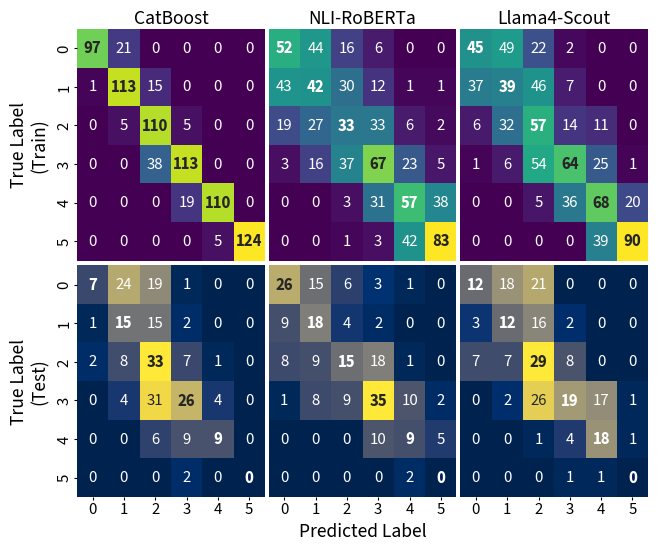

In [5]:
vis_combined_conf_matrices_train_test(encoder_models, nli_models, llm_models)